In [1]:
import pandas as pd

df = pd.read_csv("data.csv")
df.head() #check karega ki data aya ki nahi 

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [5]:
#since data exist kar raha hai it comes next step
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [3]:
# yaha humne datatypes and summary statics ko check kara so next step
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

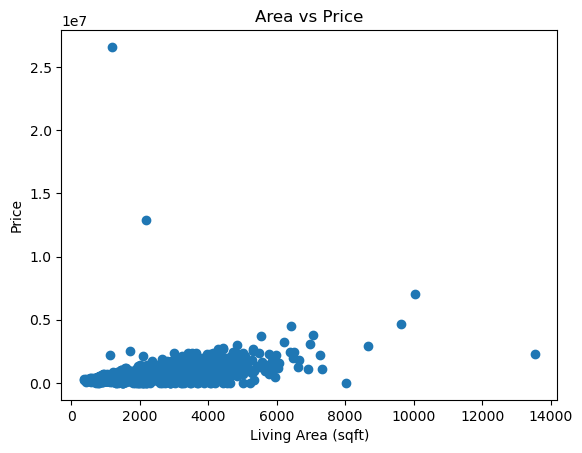

In [6]:
plt.scatter(df['sqft_living'], df['price'])
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

In [8]:
#yaha graph ka output aa gaya  
X = df[['sqft_living', 'bedrooms', 'bathrooms', 'floors', 'view']]
y = df['price']

In [9]:
# yaha sare features select ho gaye
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
#model ko regregate karna start kar diya 
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
#traiing complete ho gaya
y_pred = model.predict(X_test)

print(y_pred[:8])

[ 366445.13361791  389799.34670613 1024020.7668002   550947.32040745
  416476.15360371  693729.71091938  481765.8065532   489221.47807202]


In [13]:
# ek data ko predict bhi kara diya 
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 989906638552.2268


In [14]:
#acuuracy checked and results are satisfactory
output = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

output.to_csv("output.csv", index=False)

In [16]:
#custom prediction model ready just input the values jis sequence me manga hai usi me 
import pandas as pd

sample = pd.DataFrame([[2000, 3, 2, 2, 1]], 
                      columns=['sqft_living', 'bedrooms', 'bathrooms', 'floors', 'view'])

prediction = model.predict(sample)
print("Predicted Price:", prediction[0])

Predicted Price: 598055.4966957967
